# TwoBoxCarbon and BoxModelSpec — Carbon Cycle Box Models

## Overview

Two complementary approaches to building box models in ClimateCritters.

### TwoBoxCarbon

A concrete model tracking atmospheric (`A`) and surface-ocean (`S`) carbon inventories.
Exchange is driven by the **concentration** gradient (not raw inventory difference),
so mass conservation holds even when boxes have different volumes:

$$F_{A\leftrightarrow S} = k\left(\frac{A}{V_{\text{atm}}} - \frac{S}{V_{\text{surf}}}\right)$$

$$\frac{dA}{dt} = -F + R - l_s A \qquad \frac{dS}{dt} = F$$

### BoxModelSpec

A declarative framework for building any ODE box model without writing a full `CCModel`
subclass. Supports explicit callable tendencies **or** automatic network assembly from
reciprocal exchange and directed transport terms.

### Parameters — TwoBoxCarbon

| Name | Description | Default |
|------|-------------|--------|
| `k` | Air-sea exchange rate constant | 0.2 |
| `R` | Atmospheric carbon source flux | 0.0 |
| `l_s` | First-order atmospheric loss | 0.0 |
| `V_atm` | Atmospheric box volume | 1.0 |
| `V_surf` | Surface-ocean box volume | 1.0 |

Diagnostic: `net_flux` (atmospheric tendency `dA/dt`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import climatecritters as cc
from climatecritters.model_critters.two_box_carbon import TwoBoxCarbon
from climatecritters.model_critters.box_model import BoxModelSpec

## TwoBoxCarbon

### Closed system: mass conservation

With `R=0` and `l_s=0` the system is closed: total carbon `A + S` must remain constant to numerical precision. This checks that the concentration-gradient exchange (not raw inventory difference) conserves mass correctly even when `V_atm ≠ V_surf`.

In [2]:
# Closed system: V_atm ≪ V_surf — atmosphere equilibrates to surface ocean concentration
model_closed = TwoBoxCarbon(k=0.2, R=0.0, l_s=0.0, V_atm=1.0, V_surf=50.0)
out_closed = model_closed.integrate(t_span=(0, 100), y0=[100.0, 200.0], method='RK45')

A_c = out_closed.state_variables['A']
S_c = out_closed.state_variables['S']
total = A_c + S_c

print(f'Initial total: {total[0]:.6f}')
print(f'Final   total: {total[-1]:.6f}')
print(f'Max drift:     {np.max(np.abs(total - total[0])):.2e}  (numerical precision)')

Initial total: 300.000000
Final   total: 300.000000
Max drift:     1.71e-13  (numerical precision)


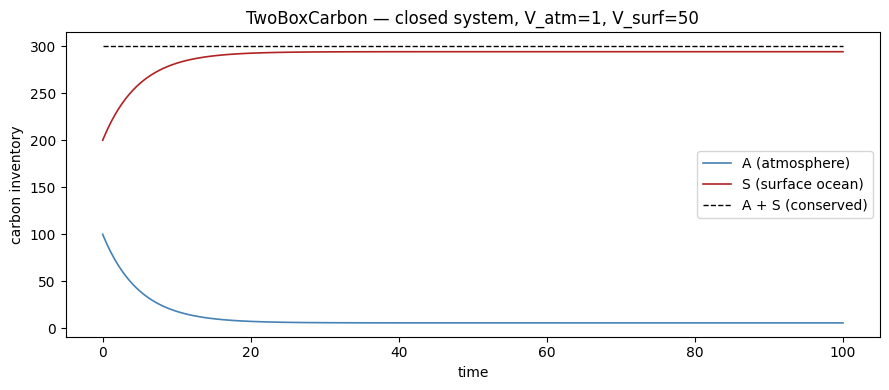

In [3]:
t_c = np.asarray(out_closed.time)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_c, A_c, color='steelblue', lw=1.2, label='A (atmosphere)')
ax.plot(t_c, S_c, color='firebrick', lw=1.2, label='S (surface ocean)')
ax.plot(t_c, total, 'k--', lw=1.0, label='A + S (conserved)')
ax.set_xlabel('time'); ax.set_ylabel('carbon inventory')
ax.set_title('TwoBoxCarbon — closed system, V_atm=1, V_surf=50')
ax.legend()
plt.tight_layout(); plt.show()

**Figure.** Both inventories relax toward a shared equilibrium concentration ($A/V_{\rm atm} = S/V_{\rm surf}$). Because $V_{\rm surf} = 50 \times V_{\rm atm}$, the atmosphere ends up with roughly 1/51 of the total carbon. The dashed `A + S` line is flat to floating-point precision throughout.

### Forced case: time-varying carbon source

A step-on/step-off pulse in `R` simulates an emission event. Registered via `register_forcing` so it is time-varying.

In [4]:
# Pulse: R=1 for 0 ≤ t < 30, then R=0 (atmosphere relaxes back)
pulse = cc.Forcing(lambda t: 1.0 if t < 30.0 else 0.0)

model_forced = TwoBoxCarbon(k=0.2, l_s=0.05, V_atm=1.0, V_surf=1.0)
model_forced.register_forcing('R', pulse)
out_forced = model_forced.integrate(t_span=(0, 150), y0=[0.0, 0.0], method='RK45')

t_f = np.asarray(out_forced.time)

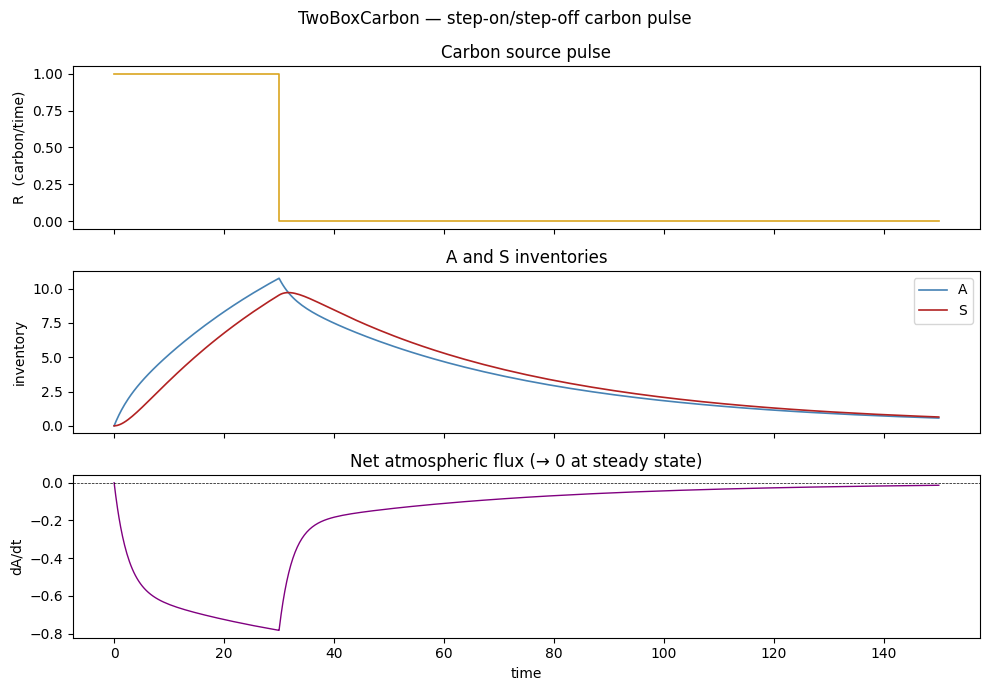

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

# Forcing
axes[0].step(t_f, [pulse.get_forcing(tt) for tt in t_f], where='post',
             color='goldenrod', lw=1.2)
axes[0].set_ylabel('R  (carbon/time)'); axes[0].set_title('Carbon source pulse')

# State variables
axes[1].plot(t_f, out_forced.state_variables['A'], color='steelblue', lw=1.2, label='A')
axes[1].plot(t_f, out_forced.state_variables['S'], color='firebrick', lw=1.2, label='S')
axes[1].set_ylabel('inventory'); axes[1].set_title('A and S inventories')
axes[1].legend()

# Net flux
axes[2].plot(t_f, out_forced.diagnostic_variables['net_flux'], color='purple', lw=1.0)
axes[2].axhline(0, color='k', lw=0.5, ls='--')
axes[2].set_ylabel('dA/dt'); axes[2].set_title('Net atmospheric flux (→ 0 at steady state)')
axes[2].set_xlabel('time')

fig.suptitle('TwoBoxCarbon — step-on/step-off carbon pulse')
plt.tight_layout(); plt.show()

**Figure.** Top: step forcing pulse ($R=1$ for $t<30$, then off). Middle: $A$ rises during the pulse then decays as air-sea exchange transfers carbon to the ocean; $S$ follows with a slight lag and retains most of the perturbation. Bottom: net atmospheric flux is positive (net source) during the pulse, then negative (net uptake by ocean) during relaxation.

## BoxModelSpec

### Declarative rebuild of TwoBoxCarbon

`BoxModelSpec` lets you define the same equations without subclassing `CCModel`. Register state variables, parameters, tendency relations, and diagnostics; call `make_boxmodel()` to get an integrable model.

The spec below reproduces `TwoBoxCarbon` exactly — outputs match to floating-point precision.

In [6]:
spec = BoxModelSpec('two_box_carbon_generic')
spec.register_state_variables(['A', 'S'])
spec.register_diagnostic_variables(['net_flux'])
spec.register_parameters(k=0.2, R=0.0, l_s=0.05, V_atm=1.0, V_surf=1.0)
spec.register_input('R', fallback_param='R')   # R can be overridden by register_forcing

def exchange_flux(ctx):
    return ctx.param('k') * (ctx['A'] / ctx.param('V_atm') - ctx['S'] / ctx.param('V_surf'))

spec.register_relations({
    'A': lambda ctx: -exchange_flux(ctx) + ctx.input('R') - ctx.param('l_s') * ctx['A'],
    'S': lambda ctx:  exchange_flux(ctx),
})
spec.register_diagnostic(
    'net_flux',
    lambda ctx: -exchange_flux(ctx) + ctx.input('R') - ctx.param('l_s') * ctx['A'],
)

model_generic = spec.make_boxmodel()
model_generic.register_forcing('R', pulse)
out_generic = model_generic.integrate(t_span=(0, 150), y0=[0.0, 0.0], method='RK45')

# Verify: should match the concrete model output to floating-point precision
max_diff_A = np.max(np.abs(out_generic.state_variables['A'] - out_forced.state_variables['A']))
max_diff_S = np.max(np.abs(out_generic.state_variables['S'] - out_forced.state_variables['S']))
print(f'max |A_generic − A_concrete| = {max_diff_A:.2e}')
print(f'max |S_generic − S_concrete| = {max_diff_S:.2e}')

max |A_generic − A_concrete| = 0.00e+00
max |S_generic − S_concrete| = 0.00e+00


### Automatic network: exchange and transport

For larger networks `BoxModelSpec` supports two link types:
- **Reciprocal exchange** `register_exchange(left, right, rate)` — symmetric, concentration-gradient flux
- **Directed transport** `register_transport(source, target, rate)` — one-way, proportional to source concentration

In [7]:
three_box = BoxModelSpec('atm_surf_deep')
three_box.register_state_variables(['A', 'S', 'D'])
three_box.register_box_volumes(A=1.0, S=50.0, D=300.0)

# A ↔ S: bidirectional air-sea exchange
three_box.register_exchange('A', 'S', rate=0.2)
# S → D: biological pump (directed export from surface to deep)
three_box.register_transport('S', 'D', rate=0.05)

# External atmospheric source pulse
three_box.register_source('A', value=0.0)  # will be overridden below

model_3box = three_box.make_boxmodel()
model_3box.register_forcing('source__A', cc.Forcing(lambda t: 0.5 if t < 30 else 0.0))

# Start at approximate pre-perturbation steady state
out_3box = model_3box.integrate(t_span=(0, 200), y0=[800.0, 900.0, 37000.0], method='RK45')

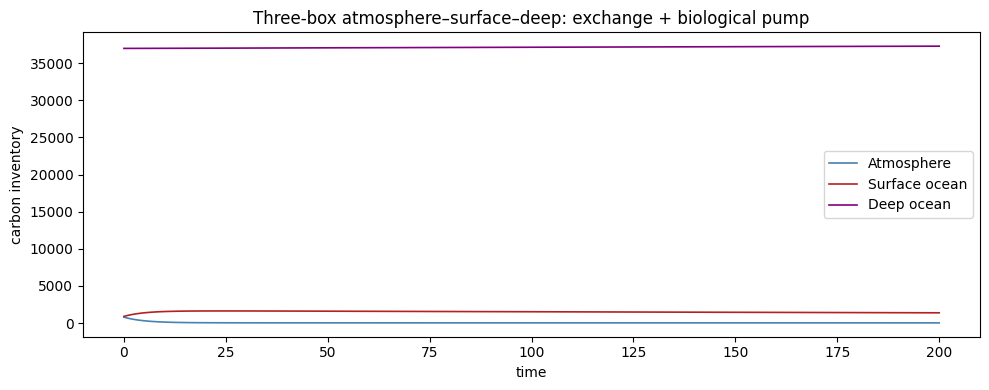

In [8]:
t_3 = np.asarray(out_3box.time)
colors_3 = ['steelblue', 'firebrick', 'purple']
boxes = ['A', 'S', 'D']
labels = ['Atmosphere', 'Surface ocean', 'Deep ocean']

fig, ax = plt.subplots(figsize=(10, 4))
for box, label, color in zip(boxes, labels, colors_3):
    ax.plot(t_3, out_3box.state_variables[box], lw=1.2, color=color, label=label)
ax.set_xlabel('time'); ax.set_ylabel('carbon inventory')
ax.set_title('Three-box atmosphere–surface–deep: exchange + biological pump')
ax.legend()
plt.tight_layout(); plt.show()

**Figure.** Three-box atmosphere–surface–deep system. During the pulse ($t < 30$) atmospheric carbon spikes and surface ocean rises slightly via air-sea exchange. After the pulse, the atmosphere relaxes quickly back toward equilibrium with the surface. The deep ocean responds on the longest timescale — the biological pump slowly transfers surface carbon downward, and by $t=200$ has absorbed most of the perturbation.

## Solver notes

`RK45` is appropriate for all box models here; none are stiff under typical parameters.

**`TwoBoxCarbon` and `GenericBoxModel` both use `uses_post_history=True`.** Diagnostics
(`net_flux`) are computed by replaying tendency callables over the solved history.

**Time-varying source terms** in the generic framework use `register_source` + a forcing
registered on the corresponding `'source__<box>'` parameter:
```python
spec.register_source('A', value=0.0)
model.register_forcing('source__A', cc.Forcing(lambda t: ...))
```

**Common pitfall:** `register_exchange('A', 'S', ...)` and `register_exchange('S', 'A', ...)`
would double-count the same reciprocal pathway. Always register each exchange pair once.